# Bibliotecas

In [ ]:
!pip install transformers accelerate torch smolagents diffusers ddgs --q
from huggingface_hub import login
login("TOKEN") #crear TOKEN en Hugging Face

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.5/161.5 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.7/161.7 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 62.0 MB/s eta 0:00:00


# LLM

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-1.5B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)

prompt = "Give me a short introduction to large language model."
messages = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=512
)
generated_ids = [
    output_ids[len(input_ids):] for input_ids, output_ids in zip(model_inputs.input_ids, generated_ids)
]

response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]

response

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/7.30k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

'A large language model is a type of artificial intelligence (AI) system that can generate human-like text based on the input it receives. These models are designed to understand and respond to natural language queries or prompts in order to provide useful information, answer questions, or engage in conversation with humans.\n\nThe size of these models refers to the amount of data they have been trained on, which typically ranges from millions to billions of words. This allows them to learn complex patterns and relationships between different pieces of information, enabling them to produce responses that are more accurate and contextually relevant than those generated by simpler AI systems.\n\nLarge language models have many potential applications, including chatbots for customer service, virtual assistants for personal assistants, translation tools, and even writing assistance for writers. However, they also raise important ethical concerns about privacy, bias, and accountability, as 

# Imágenes

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

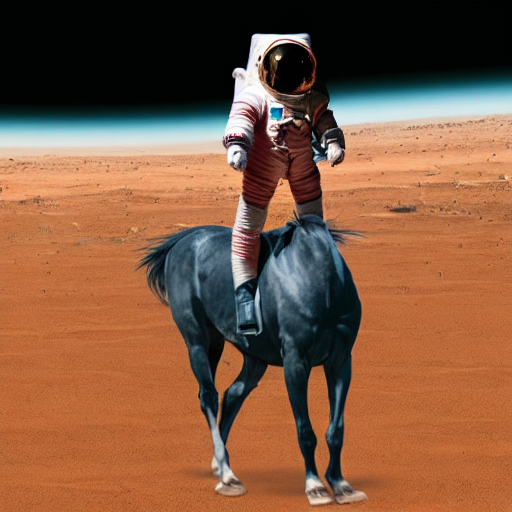

In [ ]:
from diffusers import StableDiffusionPipeline
import torch

model_id = "sd-legacy/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

prompt = "a photo of an astronaut riding a horse on mars"
image = pipe(prompt).images[0]

image

# Agentes

In [ ]:
from smolagents import CodeAgent, InferenceClientModel

model_id = "Qwen/Qwen2.5-72B-Instruct"

agent = CodeAgent(
    tools=[],
    model=InferenceClientModel(model_id=model_id),
    add_base_tools=True
)

agent.run("Cuál es el primer partido de Argentina en el mundial 2026")

╭──────────────────────────────────────────────────── New run ────────────────────────────────────────────────────╮
│                                                                                                                 │
│ Cuál es el primer partido de Argentina en el mundial 2026                                                       │
│                                                                                                                 │
╰─ InferenceClientModel - Qwen/Qwen2.5-72B-Instruct ──────────────────────────────────────────────────────────────╯

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 1 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  result = web_search(query="primer partido de Argentina en el mundial 2026")                                      
  print(result)                                                                                                    
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Execution logs:
## Search Results

[Argentina en la Copa Mundial de Fútbol de 2026 - Wikipedia, la enciclopedia 
libre](https://es.wikipedia.org/wiki/Argentina_en_la_Copa_Mundial_de_Fútbol_de_2026)
9 hours ago - En la fecha 15, el 5 de junio, tras la victoria 1-0 contra Chile de visitante, los argentinos 
aseguraron el primer puesto. Será la decimonovena participación de Argentina, que formará parte del Grupo J, junto 
a Argelia, Austria y Jordania. Datos correspondientes al periodo entre la finalización ...

[Argentina debutó en el Mundial 2026 con goleada a Argelia y festival de Lionel Messi: reviví lo mejor - TyC 
Sports](https://www.tycsports.com/seleccion-argentina/cuando-juega-argentina-vs-argelia-por-el-mundial-2026-fecha-h
ora-y-sede-id702534.html)
Szymon Marciniak, el árbitro de la final de Qatar 2022, dirigirá el debut de Argentina en el Mundial 2026 (Getty 
Images) ... A dos horas y media del comienzo del partido, los primeros hinchas comienzan a ingresar al estadio que 
albergará ... Published 8 hours ago

[Arrancó el Mundial de Fútbol 2026: cuándo debuta Argentina y cuáles son las fechas claves de la fase de grupos - 
Chequeado](https://chequeado.com/el-explicador/mundial-2026-cuando-debuta-la-seleccion-argentina-y-cuales-son-las-f
echas-claves-de-la-fase-de-grupos/)
1 week ago - El debut de la Selección argentina será frente a Argelia el próximo martes 16 de junio a las 22 hs en 
el estadio Arrowhead de Kansas City. El segundo partido de la Selección será el lunes 22 de junio a las 14 hs 
contra Austria en el estadio ...

[Primer partido de la selección argentina en el Mundial 2026: cuándo es y contra quién juega - LA 
NACION](https://www.lanacion.com.ar/deportes/futbol/primer-partido-de-la-seleccion-argentina-en-el-mundial-2026-cua
ndo-es-y-contra-quien-juega-nid06062026/)
2 weeks ago - A la ilusión habitual que compone el andamiaje de los equipos que disputan un Mundial, la selección 
argentina le suma el suyo, propio: conseguir la épica que nadie logra hace más de cinco décadas: conservar el 
título de campeón. En este sentido, la albiceleste, que se consagró en Qatar 2022 y hoy es la N° 2 del mundo detrás
de España, quiere seguir agrandando su legado y para ello no puede permitirse mucho paso en falso. Integrará el 
Grupo J, en el que es cabeza de serie, y tendrá como primer desafío enfrentar a Argelia.

[Scaloni definió la formación de la Selección Argentina vs Argelia en el Mundial 2026: la defensa que lo convenció,
un debut absoluto y quién es el 
"9"](https://www.clarin.com/deportes/scaloni-definio-formacion-seleccion-argentina-vs-argelia-mundial-2026-defensa-
convencio-debut-absoluto-9_0_8FKLdY2uoB.html)
19 hours ago - Todos unidos. La foto grupal de la Selección Argentina antes del debut contra Argelia en el Mundial 
2026 y el recuerdo para Leo Balerdi, el jugador que fue desafectado por una lesión.

[Hoy juega Argentina su debut en el Mundial 2026 ante Argelia: dónde ver el partido y a qué 
hora](https://www.ambito.com/deportes/cuando-juega-argentina-el-primer-partido-del-mundial-2026-rival-horario-y-don
de-verlo-n6287208)
1 day ago - Por primera vez participan 48 selecciones y el torneo se desarrolla en tres países anfitriones: Estados
Unidos, México y Canadá. ... Argentina hará su debut en el Mundial 2026 este martes 16 de junio frente a Argelia.

[Fixture de Argentina en el Mundial 2026: partidos y 
horarios](https://www.clarin.com/deportes/fixture-argentina-mundial-2026-partidos-horarios_0_6EZb5exLXt.html)
2 weeks ago - El estreno de la Argentina será el martes 16 de junio de 2026 a las 22.00 (hora argentina) frente a 
Argelia, en Kansas City. Será el primer paso del equipo dirigido por Lionel Scaloni en la defensa del título 
obtenido en Qatar 2022.

[Así le contamos el partido entre Argentina y Argelia del Mundial 2026 y el triplete de Messi en su debut | EL PAÍS
Argentina](https://elpais.com/argentina/2026-06-17/argentina-argelia-el-partido-del-mundial-2026-en-vivo.html)
15 hours ago - Con un ca

[Step 1: Duration 5.96 seconds| Input tokens: 2,144 | Output tokens: 77]

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ Step 2 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

─ Executing parsed code: ──────────────────────────────────────────────────────────────────────────────────────── 
  final_answer("Argentina's first match in the 2026 World Cup is against Argelia on June 16, 2026, at 10 PM        
  Argentina time.")                                                                                                
 ─────────────────────────────────────────────────────────────────────────────────────────────────────────────────

Final answer: Argentina's first match in the 2026 World Cup is against Argelia on June 16, 2026, at 10 PM Argentina
time.

[Step 2: Duration 5.64 seconds| Input tokens: 6,002 | Output tokens: 182]

"Argentina's first match in the 2026 World Cup is against Argelia on June 16, 2026, at 10 PM Argentina time."